# 📈 Exploratory Data Analysis — Stock Valuation Dataset
---
## Overview
This notebook is the **second stage** of the project — the Exploratory Data Analysis (EDA) phase.

Before we train any machine learning model, it is essential to deeply understand the data:
- Does it have missing values?
- Are the three valuation classes balanced?
- Do the features (PE Ratio, ROE, Momentum, etc.) actually differ meaningfully across classes?
- Are any features highly correlated with each other or with the target?

**Answering these questions gives us confidence that the model will learn something real, not spurious patterns.**

---
## What This Notebook Covers

| Section | What We Do | Key Insight |
|---|---|---|
| Structure Review | Check column names and types | Confirms expected 13 features |
| Missing Values | Check for NaNs | Any gaps that could affect training |
| Descriptive Stats | Mean, std, min/max per feature | Overall ranges and scales |
| Class Distribution | Count of 0/1/2 labels | Confirms the dataset is balanced |
| Feature Stats by Class | Mean/median/std per feature per class | Do features actually separate classes? |
| Bell Curve Plots | KDE (kernel density) plots per feature | Visual proof of class separation |
| Sector Analysis | PE Ratio by sector and valuation class | Structural sector differences |
| ROE vs PE Scatter | Scatter coloured by class | Quality-value cluster identification |
| Correlation Matrix | Heatmap of all feature correlations | Feature redundancy and relationships |
| Target Correlation | Bar chart of feature-to-target correlation | Most predictive features for the model |

---
## The Target Variable Explained

| Label | Meaning | Graham Rule |
|---|---|---|
| `0` | **Undervalued** | Price < Graham Value × 0.85 |
| `1` | **Fair Value** | Price within ±15% of Graham Value |
| `2` | **Overvalued** | Price > Graham Value × 1.15 |

## 1. Library Imports

In [3]:
import pandas as pd        # Data manipulation and analysis
import numpy as np         # Numerical operations
import matplotlib.pyplot as plt  # Plotting and charts
import seaborn as sns      # Statistical visualisation (heatmaps, KDE plots, etc.)

## 2. Loading the Dataset
We load the pre-built CSV file created in the Data Collection notebook (`dataset.ipynb`).  
This CSV contains one row per trading day per stock, with 13 engineered financial features and a `Target` label.

In [4]:
df = pd.read_csv('balanced_stock_data.csv')

## 3. Structure & Column Review
The first step in any EDA is to **understand what columns exist** in the dataset.  
This confirms that all 13 features were saved correctly and the column names match what the model will expect during training.

We also check that the `Target`, `Sector`, and `Ticker` metadata columns are present.

In [5]:
print("### 1. Structure & Column Review")
print(df.columns)

### 1. Structure & Column Review
Index(['PE_Ratio', 'ROE', 'ROA', 'EPS', 'Dividend_Yield', 'Debt_to_Equity',
       'Price_to_Book', 'Price_to_Sales', 'Revenue_Growth', 'Operating_Margin',
       'Momentum', 'Volatility', 'sp500_close', 'Target', 'Sector', 'Ticker'],
      dtype='object')


## 4. Missing Value Check
**Before any analysis or modelling, we must check for null/missing values.**  
A missing value in a feature column would cause errors in sklearn models (most models cannot handle NaNs natively).

`isnull().sum()` returns the count of missing values per column.  
> ✅ **Goal:** All columns should show `0` — confirming that the dataset is clean and complete.

In [6]:
df.isnull().sum()

PE_Ratio            0
ROE                 0
ROA                 0
EPS                 0
Dividend_Yield      0
Debt_to_Equity      0
Price_to_Book       0
Price_to_Sales      0
Revenue_Growth      0
Operating_Margin    0
Momentum            0
Volatility          0
sp500_close         0
Target              0
Sector              0
Ticker              0
dtype: int64

## 5. Descriptive Statistics
`df.describe()` provides a statistical summary of every numeric column:
- **count**: number of non-null values (should be the same for all features)
- **mean**: average value — gives a sense of typical magnitudes
- **std**: standard deviation — how spread out the values are
- **min / max**: extreme values — useful for spotting outliers
- **25% / 50% / 75%**: quartiles — the distribution shape

> 💡 **Key observation to make here:** Features like `PE_Ratio` and `Volatility` likely have very different scales.  
> This is important — tree-based models (Random Forest, XGBoost) handle this fine, but KNN and Neural Networks require **feature scaling** (StandardScaler).

In [7]:
df.describe()

,PE_Ratio,ROE,ROA,EPS,Dividend_Yield,Debt_to_Equity,Price_to_Book,Price_to_Sales,Revenue_Growth,Operating_Margin,Momentum,Volatility,sp500_close,Target
count,1995.000000,1995.000000,1995.000000,1995.000000,1995.000000,1995.000000,1995.000000,1995.000000,1995.000000,1995.000000,1995.000000,1995.000000,1995.000000,1995.000000
mean,22.848010,0.239010,0.085294,7.827561,2.543629,1.031430,5.778546,5.513434,0.103510,0.219075,1.000059,0.019257,5000.662523,1.000000
std,57.660467,0.641842,0.083235,12.276514,1.649623,3.689627,18.088532,12.110361,0.277153,0.146284,0.069017,0.008756,1035.430334,0.816701
min,-66.715623,-4.520528,-0.264737,-27.735099,0.000000,-16.598240,-80.212915,0.243567,-0.280000,-0.435798,0.760097,0.005315,3577.030029,0.000000
25%,8.401106,0.081997,0.031153,2.394572,1.390000,0.314041,1.355216,1.633588,-0.011000,0.120691,0.960032,0.013207,4091.949951,0.000000
50%,16.094826,0.169429,0.069138,5.191370,2.530000,0.571137,2.026656,3.319507,0.062000,0.208017,1.000675,0.016864,4698.350098,1.000000
75%,24.812944,0.327054,0.140267,10.177942,3.400000,1.115161,4.479307,5.687130,0.131000,0.300609,1.041003,0.023041,5881.629883,2.000000
max,966.065967,14.504789,0.653041,172.674965,9.230000,55.539846,340.084356,159.896084,1.963000,0.703101,1.346214,0.062131,6978.600098,2.000000


## 6. Target Class Distribution

### Why This Matters
If the dataset is **imbalanced** (e.g., 80% Fair Value, 10% Undervalued, 10% Overvalued), the model will be biased toward predicting "Fair Value" for everything.

The proportional breakdown (`normalize=True`) shows us the fraction of the dataset each class occupies.  
The bar chart makes this visually immediate.

> ✅ **Goal:** All three classes should have roughly equal counts (~33% each), confirming the anti-bias balancing we applied in the collection notebook worked correctly.

In [8]:
print(df['Target'].value_counts(normalize=True))

Target
2    0.333333
1    0.333333
0    0.333333
Name: proportion, dtype: float64


Target
2    665
1    665
0    665
Name: count, dtype: int64


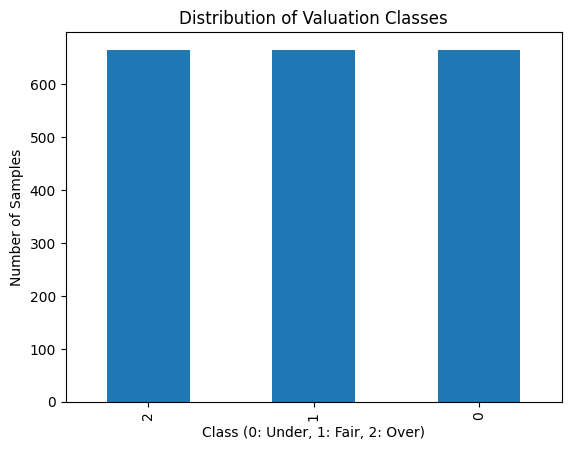

In [9]:
print(df['Target'].value_counts())
# Visualize for your report
df['Target'].value_counts().plot(kind='bar', title='Distribution of Valuation Classes')
plt.xlabel('Class (0: Under, 1: Fair, 2: Over)')
plt.ylabel('Number of Samples')
plt.show()
#reduce bias is overvalued set take out remove sample classes for targets 
#use my dataset manual to check out from the data  
#varation of data  mean mode and std

## 7. Feature Statistics by Class
This is the **most analytically important section** of the EDA.

For each of the 6 key features, we calculate the **mean, median, and standard deviation grouped by Target class**.  
This tells us: *do the feature values actually differ between Undervalued, Fair, and Overvalued stocks?*

**If they do differ** — the feature carries signal, and the model can use it to distinguish classes.  
**If they don't differ** — the feature is likely not informative and the model may struggle.

### Features Analysed:

| Feature | Expected Pattern |
|---|---|
| `PE_Ratio` | Overvalued stocks should have higher PE (market paying more per £1 of earnings) |
| `ROE` | Undervalued stocks may have strong ROE that the market hasn't yet priced in |
| `Momentum` | Overvalued stocks may have had recent price surges (high momentum) |
| `Volatility` | Undervalued stocks are sometimes beaten-down and more volatile |
| `Debt_to_Equity` | High D/E might suppress valuation or push labels toward "Overvalued" for risky firms |
| `Revenue_Growth` | High growth stocks may command "Overvalued" premiums |

> The summary table is also saved to `feature_variation_summary.csv` for dissertation tables.

In [10]:
# List the features you want to analyze (excluding the Target itself)
# These should match the names in your CSV
analysis_features = ['PE_Ratio', 'ROE', 'Momentum', 'Volatility', 'Debt_to_Equity', 'Revenue_Growth']

print("--- DESCRIPTIVE STATISTICS BY CLASS ---")
print("Class 0: Undervalued | Class 1: Fair | Class 2: Overvalued\n")

for feat in analysis_features:
    if feat in df.columns:
        print(f"Analysis for: {feat}")
        
        # Calculate stats grouped by the Target class
        stats = df.groupby('Target')[feat].agg(['mean', 'median', 'std']).round(3)
        
        # Renaming for clarity in your report
        stats.index = ['Undervalued (0)', 'Fair (1)', 'Overvalued (2)']
        print(stats)
        print("-" * 40)

# Save this summary to a CSV so you can put it in your dissertation table
summary_table = df.groupby('Target')[analysis_features].agg(['mean', 'std']).round(3)
summary_table.to_csv('feature_variation_summary.csv')
print("\nSummary table saved to 'feature_variation_summary.csv'")# List the features you want to analyze (excluding the Target itself)
# These should match the names in your CSV
analysis_features = ['PE_Ratio', 'ROE', 'Momentum', 'Volatility', 'Debt_to_Equity', 'Revenue_Growth']

print("--- DESCRIPTIVE STATISTICS BY CLASS ---")
print("Class 0: Undervalued | Class 1: Fair | Class 2: Overvalued\n")

for feat in analysis_features:
    if feat in df.columns:
        print(f"Analysis for: {feat}")
        
        # Calculate stats grouped by the Target class
        stats = df.groupby('Target')[feat].agg(['mean', 'median', 'std']).round(3)
        
        # Renaming for clarity in your report
        stats.index = ['Undervalued (0)', 'Fair (1)', 'Overvalued (2)']
        print(stats)
        print("-" * 40)

# Save this summary to a CSV so you can put it in your dissertation table
summary_table = df.groupby('Target')[analysis_features].agg(['mean', 'std']).round(3)

print("\nSummary table saved to 'feature_variation_summary.csv'")

--- DESCRIPTIVE STATISTICS BY CLASS ---
Class 0: Undervalued | Class 1: Fair | Class 2: Overvalued

Analysis for: PE_Ratio
                   mean  median     std
Undervalued (0)   8.403   8.266   5.072
Fair (1)         15.197  16.305  18.352
Overvalued (2)   44.944  25.797  94.155
----------------------------------------
Analysis for: ROE
                  mean  median    std
Undervalued (0)  0.175   0.162  0.205
Fair (1)         0.363   0.213  0.556
Overvalued (2)   0.179   0.139  0.929
----------------------------------------
Analysis for: Momentum
                  mean  median    std
Undervalued (0)  0.986   0.985  0.068
Fair (1)         0.994   0.996  0.068
Overvalued (2)   1.021   1.017  0.066
----------------------------------------
Analysis for: Volatility
                  mean  median    std
Undervalued (0)  0.021   0.018  0.009
Fair (1)         0.019   0.017  0.009
Overvalued (2)   0.017   0.015  0.008
----------------------------------------
Analysis for: Debt_to_Equity
  

## 8. Bell Curve (KDE) Distributions by Class
**KDE (Kernel Density Estimation) plots** show the probability distribution of a feature's values — essentially a smoothed histogram.

### What We're Looking For
For a feature to be **useful** to the model, the three coloured curves (green = Undervalued, blue = Fair, red = Overvalued) should be **separated** — different peaks or different spreads.

- **Good separation** → Feature helps distinguish classes → Model will use this feature
- **Overlapping curves** → Feature is less discriminative → Model may ignore it

### Interpretation Tips

| Pattern | Meaning |
|---|---|
| Overvalued (red) peak further right on PE_Ratio | Expensive stocks really do have higher PE |
| Undervalued (green) peak further right on Volatility | Beaten-down stocks are indeed more volatile |
| All three curves almost identical | Feature doesn't separate classes well |

> These plots are saved as `feature_bell_curves.png` for dissertation inclusion.

Success: Bell curves saved as feature_bell_curves.png


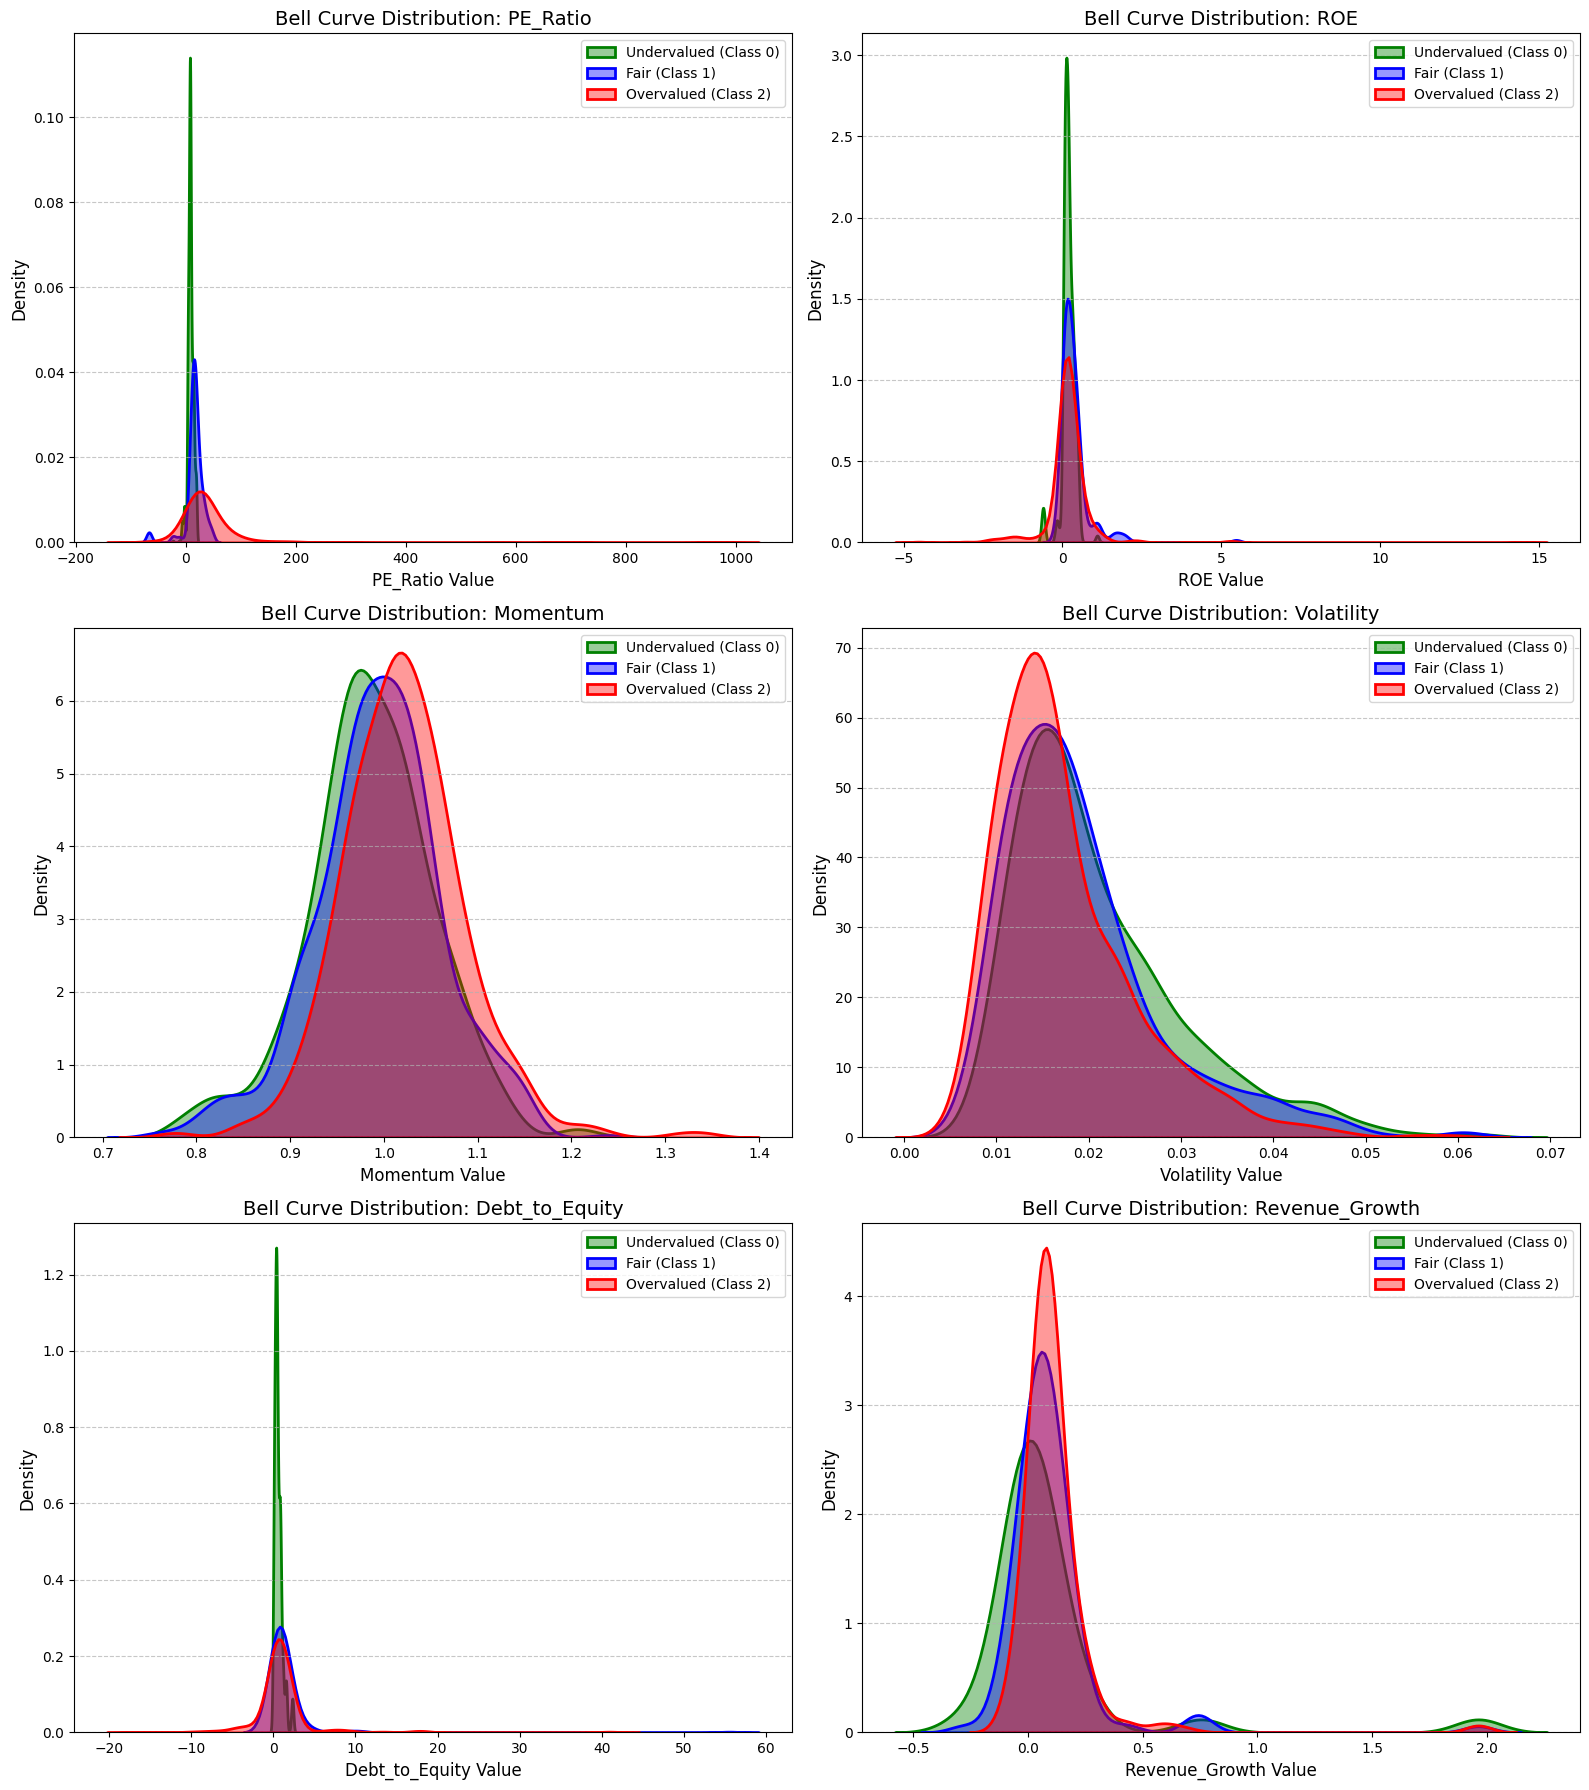

In [11]:
# Filter only features that exist in the dataframe
features_to_plot = [f for f in analysis_features if f in df.columns]

if not features_to_plot:
    print("Error: None of the requested features found in the CSV.")
else:
    # UPDATED: Changed grid to 3 rows, 2 columns to fit all 6 features
    plt.figure(figsize=(16, 18)) 
    
    # Define colors for the classes
    palette = {0: 'green', 1: 'blue', 2: 'red'}
    labels = {0: 'Undervalued (Class 0)', 1: 'Fair (Class 1)', 2: 'Overvalued (Class 2)'}
    
    for i, feature in enumerate(features_to_plot):
        # UPDATED: (3 rows, 2 columns, index)
        plt.subplot(3, 2, i + 1) 
        
        # Create the bell curves (KDE plots)
        for target_val in sorted(df['Target'].unique()):
            subset = df[df['Target'] == target_val]
            sns.kdeplot(subset[feature], 
                        fill=True, 
                        label=labels.get(target_val, f'Class {target_val}'), 
                        color=palette.get(target_val, 'gray'),
                        alpha=0.4,
                        linewidth=2)
        
        plt.title(f'Bell Curve Distribution: {feature}', fontsize=14)
        plt.xlabel(f'{feature} Value', fontsize=12)
        plt.ylabel('Density', fontsize=12)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.legend()

    plt.tight_layout()
    plt.savefig('feature_bell_curves.png')
    print("Success: Bell curves saved as feature_bell_curves.png")

## 9. PE Ratio Distribution by Sector
This boxplot explores whether the **same PE Ratio means different things in different sectors**.

### Why This Matters
A PE of 30 might be considered normal for a high-growth Technology company but extreme for a Utility company.  
If we don't account for this, the model might wrongly label all high-PE tech stocks as "Overvalued".

### Reading the Plot
- Each box covers the interquartile range (25th–75th percentile) of PE within that sector and class
- The whiskers show the full range (excluding outliers)
- Outlier dots are individual stocks with unusually high or low PE

> ⚠️ We use a **log scale** on the Y-axis because PE Ratios vary wildly (from negative to hundreds).  
> Without log scale, a few extreme outliers would compress all other boxes to near-zero.

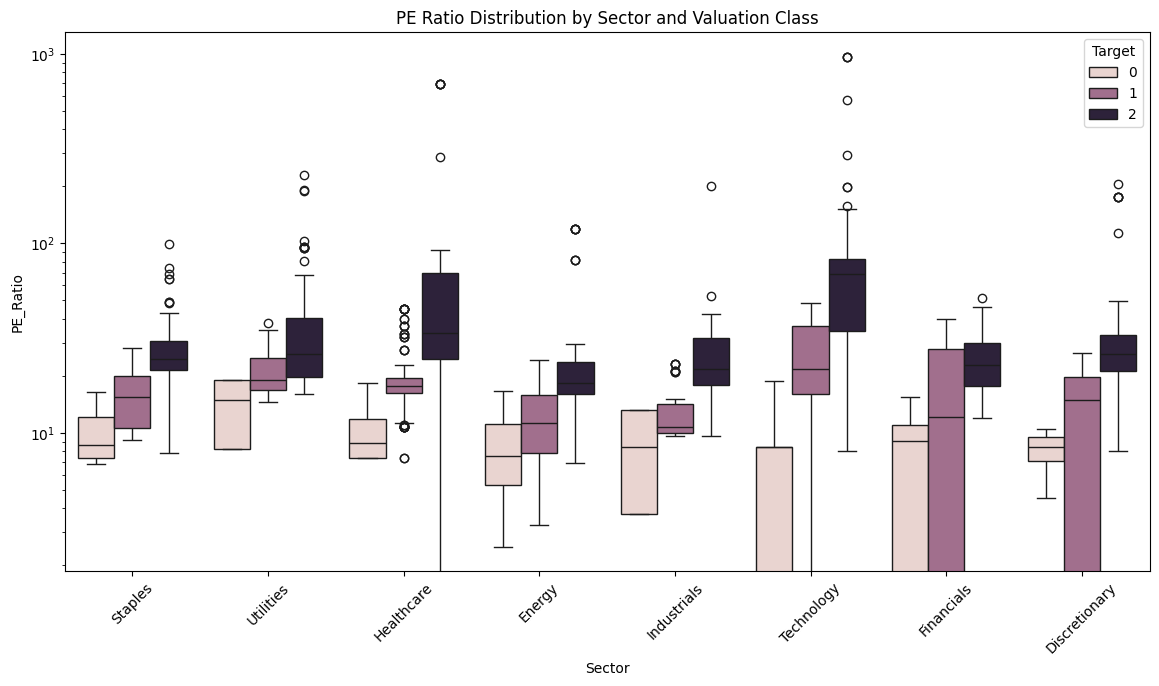

In [12]:
# Compare PE Ratios across sectors to find outliers or structural biases
plt.figure(figsize=(14, 7))
sns.boxplot(x='Sector', y='PE_Ratio', hue='Target', data=df)
plt.yscale('log') # Use log scale because PE Ratios vary wildly
plt.xticks(rotation=45)
plt.title("PE Ratio Distribution by Sector and Valuation Class")
plt.show()

## 10. ROE vs PE Ratio Scatter — Quality-Value Clusters
This scatter plot combines two of the most important valuation signals:

| Axis | Meaning |
|---|---|
| X-axis (PE Ratio) | How expensive the stock is relative to earnings |
| Y-axis (ROE) | How efficiently the company generates profit from equity |
| Colour | Valuation class (0=Undervalued, 1=Fair, 2=Overvalued) |

### What to Look For
- **Top-left quadrant** (Low PE, High ROE): These are the "quality bargains" — efficient companies trading cheaply. We'd expect these to be labelled Undervalued (Class 0) by Graham.
- **Bottom-right quadrant** (High PE, Low ROE): Expensive stocks with poor returns — likely Overvalued.
- **The black horizontal dashed line** marks ROE = 0. Companies below this line are currently losing money.

> 💡 The X and Y axes are **zoomed in** (`xlim(0,50)`, `ylim(-20,50)`) to focus on the "normal" range and exclude extreme outliers that would compress the interesting clusters.

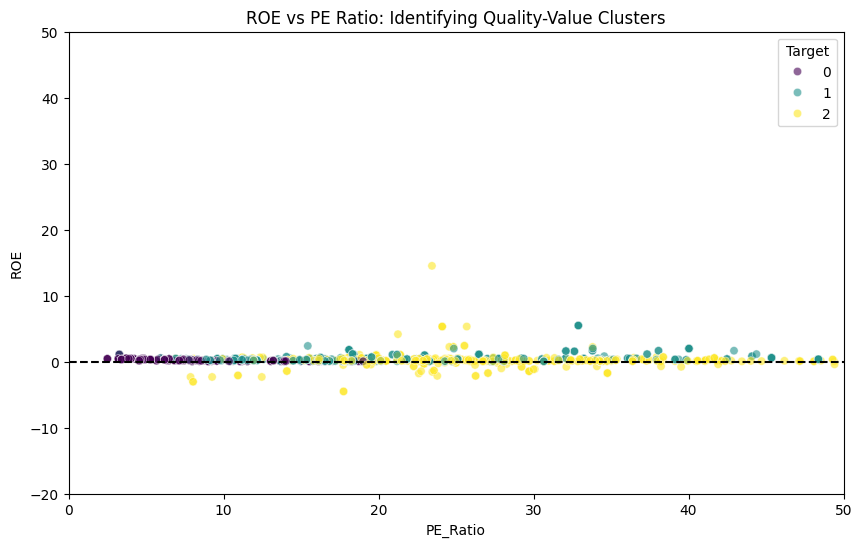

In [13]:
plt.figure(figsize=(10, 6))
# Plot ROE vs PE Ratio, colored by the AI's Target Label
sns.scatterplot(data=df, x='PE_Ratio', y='ROE', hue='Target', alpha=0.6, palette='viridis')
plt.xlim(0, 50) # Zoom in on the "Normal" range
plt.ylim(-20, 50)
plt.axhline(0, color='black', linestyle='--')
plt.title("ROE vs PE Ratio: Identifying Quality-Value Clusters")
plt.show()

## 11. Feature Correlation Matrix
The **correlation matrix** shows the pairwise relationship between every numeric feature.

### Reading the Heatmap
- Values range from **−1** (perfect negative correlation) to **+1** (perfect positive correlation)
- **+1 (dark red)**: Features move together — as one increases, the other increases
- **−1 (dark blue)**: Features move in opposite directions
- **~0 (white)**: Features are independent

### Why This Matters for Machine Learning
- **Highly correlated features** (e.g., >0.9) are redundant — they add noise without adding information
- **Features correlated with the Target** (last row/column) are the most predictive
- This matrix also warns us about **multicollinearity**, which can destabilise some model types

> The correlation heatmap is saved as `correlation_heatmap.png` for your report.

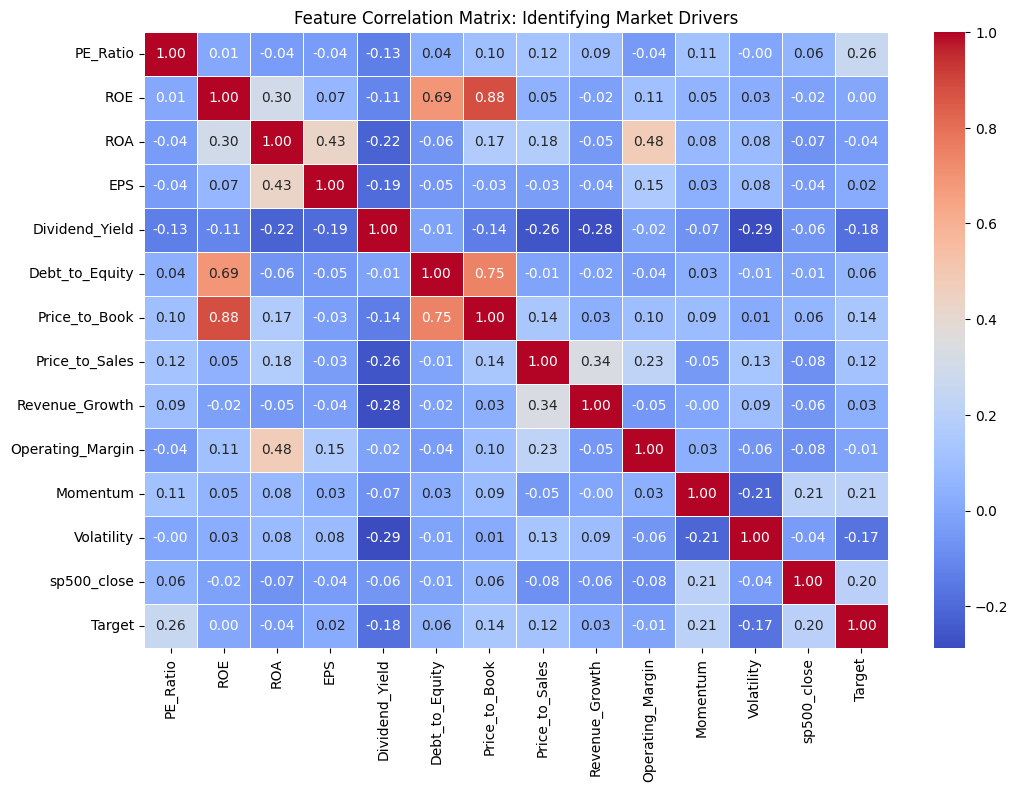

In [14]:
corr_matrix = df.drop(['Ticker', 'Sector','Timestamp'], axis=1, errors='ignore').corr()

plt.figure(figsize=(12, 8)) 
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5) 
plt.title("Feature Correlation Matrix: Identifying Market Drivers") 
plt.savefig("correlation_heatmap.png") 
plt.show()

## 12. Feature Correlation with Target (Bar Chart)
While the full heatmap shows all pairwise correlations, this focused bar chart answers the single most important EDA question:

> **Which features are most predictive of whether a stock is Undervalued, Fair, or Overvalued?**

### How to Read This Chart
- **Tall positive bars**: As the feature increases, the stock is more likely to be Overvalued (higher Target number)
- **Tall negative bars**: As the feature increases, the stock is more likely to be Undervalued (lower Target number)
- **Bars near zero**: The feature has little direct linear relationship with the Target

### Important Note on Limitations
This only captures **linear** relationships. Tree-based models like Random Forest and XGBoost can also capture non-linear patterns, so a low correlation here doesn't mean a feature is useless for those models.

> The chart is saved as `correlation_barchart.png` for your dissertation.

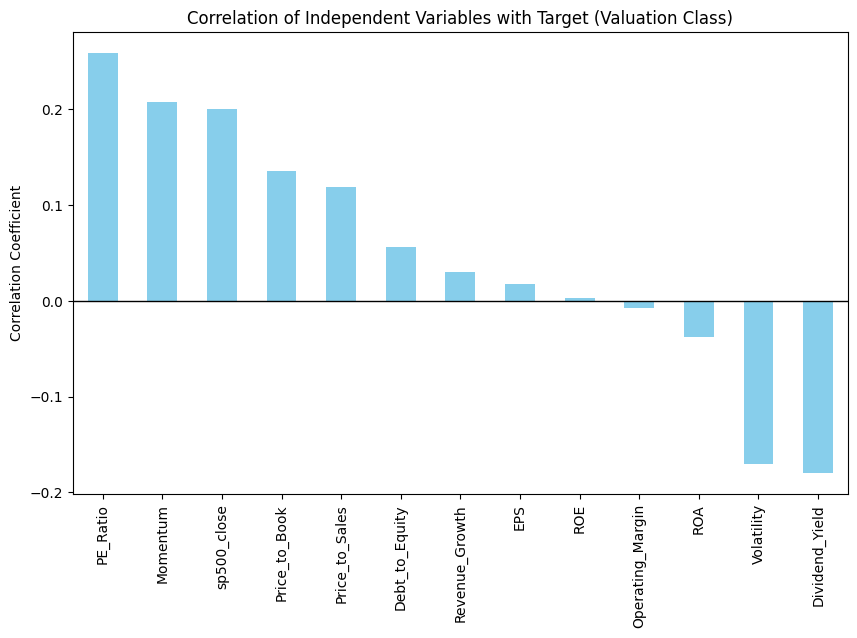

In [15]:
# 1. Drop non-numeric columns for the correlation
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# 2. Calculate the correlation specifically against the 'Target'
target_corr = numeric_df.corr()['Target'].sort_values(ascending=False)

# 3. Plotting the bar chart
plt.figure(figsize=(10, 6))
target_corr.drop('Target').plot(kind='bar', color='skyblue')
plt.title("Correlation of Independent Variables with Target (Valuation Class)")
plt.ylabel("Correlation Coefficient")
plt.axhline(0, color='black', lw=1)
plt.savefig("correlation_barchart.png")
plt.show()